In [1]:
import sys
import os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import pandas as pd

In [3]:
from datetime import datetime, timedelta

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
from skforecast.plot import calculate_lag_autocorrelation

In [40]:
#Modeling and Forecasting
import skforecast
import lightgbm
import sklearn
from lightgbm import LGBMRegressor
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive

/Users/maxwellgriffith/miniconda3/envs/loadcast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
"""
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from skforecast.plot import plot_residuals
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'font.size': 8})
"""

In [6]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [7]:
#df = pd.read_csv("../data/raw/tempload.csv", index_col = "date", parse_dates = True)
#need to drop duplicates
#idk why the extract script is buggy
#chain it all togther
# df isn't defined yet in the df["date"] call so we need to use pipe
df = (pd.read_csv("../data/raw/tempload.csv")
        .drop_duplicates()
        .pipe(lambda df: df.set_index(pd.to_datetime(df["date"])))
        .drop(columns = ["date"])
     )
#this will throw an error if there are duplicates
df.index = df.index.tz_localize(None)
df.index.freq = 'h'

In [9]:
# check that the index is complete
start_date = df.index.min()
end_date = df.index.max()
complete_date_range = pd.date_range(start=start_date, end=end_date, freq=df.index.freq)
is_index_complete = (df.index == complete_date_range).all()
print(f"Index complete: {is_index_complete}")
print(f"Number of rows with missing values: {df.isnull().any(axis=1).mean()}")

Index complete: True
Number of rows with missing values: 0.0009504257907542579


In [11]:
#create a copy of the data frame before we start modifying it
df0 = df.copy()

In [10]:
df.loc['2024-03-18':'2024-03-20'].head(40)

,Demand,Temperature,is_day
date,,,
2024-03-18 00:00:00,26278.0,5.0115,1
2024-03-18 01:00:00,26258.0,3.7115,0
2024-03-18 02:00:00,26250.0,3.1615,0
2024-03-18 03:00:00,26262.0,1.8115,0
2024-03-18 04:00:00,26260.0,0.4115,0
2024-03-18 05:00:00,26281.0,-0.3385,0
2024-03-18 06:00:00,26285.0,-1.1385,0
2024-03-18 07:00:00,26285.0,-1.8385,0
2024-03-18 08:00:00,26285.0,-1.9385,0


### Check and Fill NA Values and Outliers

In [12]:
#check for rows with missing values
df[df.isnull().any(axis = 1)]

,Demand,Temperature,is_day
date,,,
2024-02-20 07:00:00,NaN,3.061500,0
2024-02-20 08:00:00,NaN,2.061500,0
2024-02-20 09:00:00,NaN,1.811500,0
2024-02-20 10:00:00,NaN,1.161500,0
2024-02-20 11:00:00,NaN,1.061500,0
2024-02-20 12:00:00,NaN,0.611500,0
2024-02-20 13:00:00,NaN,-0.288500,0
2024-02-20 14:00:00,NaN,1.011500,1
2024-02-20 15:00:00,NaN,5.011500,1


In [16]:
#fill forward the NAs we will handle flat demand runs in the next steps
df.sort_index()
df["Demand"] = df["Demand"].ffill()

#check the nulls
df[df.isnull().any(axis = 1)]

,Demand,Temperature,is_day
date,,,


<Axes: xlabel='date'>

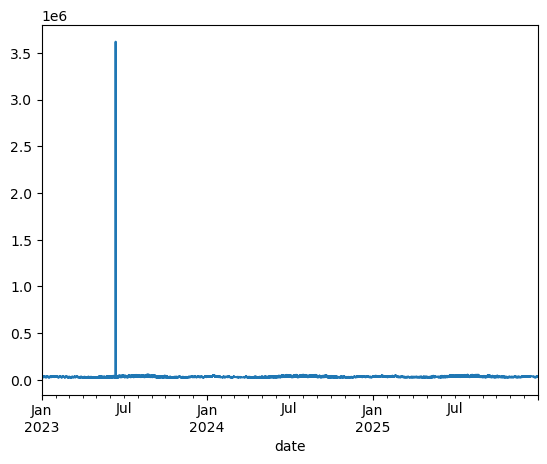

In [17]:
df.Demand.plot

In [18]:
#clearly there is an error the the data collection that we need to replace
df["Demand"] = (df["Demand"]
    .mask(df["Demand"] == df["Demand"].max())
    .ffill()
)

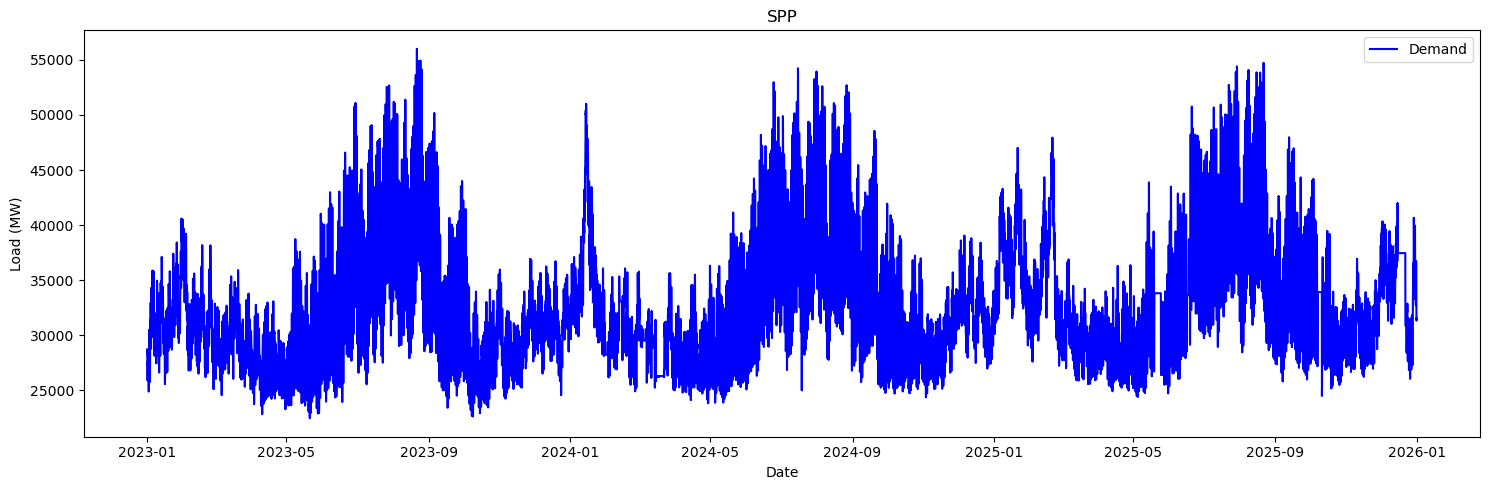

In [20]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df.index, df["Demand"], label="Demand", color="blue")

ax.set_title("SPP")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

There are some weird flat spots in the data and there might be some other anamolies that it is hard to see. Let's try other graphics

### Finding Data Anomalies

#### Heat Map of Weeks

In [15]:
# Reshape data into hour x date matrix
heatmap_data = df.copy()
heatmap_data["date_only"] = heatmap_data.index.date
heatmap_data["hour"] = heatmap_data.index.hour

pivot = heatmap_data.pivot(index="date_only", columns="hour", values="Demand")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 20))
sns.heatmap(pivot, cmap="Spectral", ax=ax, cbar_kws={"label": "Demand"})
ax.set_title("Demand Heatmap — Date vs Hour of Day")
plt.tight_layout()
plt.show()

#### Suspicious Weeks

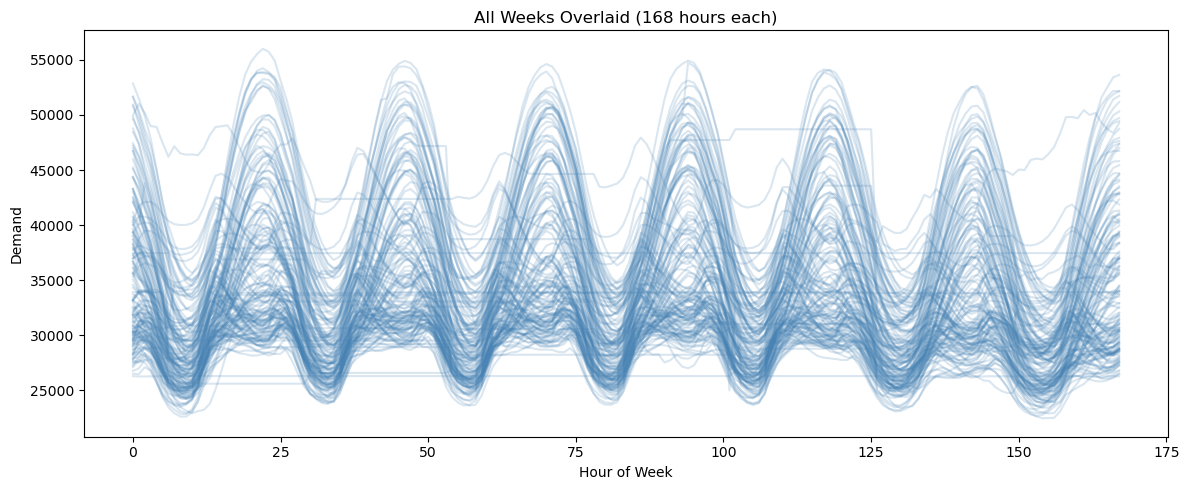

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

for year_week, group in df.groupby([df.index.year, df.index.isocalendar().week]):
    if len(group) == 168:  # full week only
        ax.plot(range(168), group["Demand"].values, alpha=0.2, color="steelblue")

ax.set_title("All Weeks Overlaid (168 hours each)")
ax.set_xlabel("Hour of Week")
ax.set_ylabel("Demand")
plt.tight_layout()
plt.show()

There are some weeks that have flat demand or stretches of flat demand that we will need to deal with. we can select them by looking at the variance across weeks

In [23]:
weekly_stats = (df
    .groupby([df.index.year, df.index.isocalendar().week])["Demand"]
    .agg(["std", "min", "max", "count"])
    .reset_index()
    .rename(columns={"date": "year", "level_1": "week"})
)

In [24]:
# Add start/end timestamps for each week
week_bounds = (df
    .groupby([df.index.year, df.index.isocalendar().week])
    .apply(lambda g: pd.Series({"start": g.index.min(), "end": g.index.max()}))
    .reset_index()
    .rename(columns={"date": "year", "level_1": "week"})
)

weekly_stats = weekly_stats.merge(week_bounds, on=["year", "week"])
weekly_stats["range"] = weekly_stats["max"] - weekly_stats["min"]

In [25]:
#let's look at the variance by week
weekly_stats["std"].describe()

count     156.000000
mean     3613.732723
std      1765.887690
min       741.355265
25%      2106.983307
50%      2777.537798
75%      5172.085888
max      7245.343477
Name: std, dtype: float64

In [26]:
# Sort by lowest variance to find flattest weeks
# if a "typical" week has a std of around 1,700 than anything well below that is worth looking at
suspicious_weeks = weekly_stats.sort_values("std").head(10)
suspicious_weeks.sort_values("start")

,year,week,std,min,max,count,start,end,range
45,2023,46,1694.684827,25117.0,31085.0,168,2023-11-13,2023-11-19 23:00:00,5968.0
56,2024,5,1671.380856,26159.0,36071.0,168,2024-01-29,2024-02-04 23:00:00,9912.0
57,2024,6,1696.828096,26894.0,35287.0,168,2024-02-05,2024-02-11 23:00:00,8393.0
61,2024,10,1379.732432,25683.0,32378.0,168,2024-03-04,2024-03-10 23:00:00,6695.0
63,2024,12,1627.967211,26187.0,31232.0,168,2024-03-18,2024-03-24 23:00:00,5045.0
99,2024,48,1705.903841,26741.0,35705.0,168,2024-11-25,2024-12-01 23:00:00,8964.0
103,2024,52,1621.748253,26973.0,33363.0,168,2024-12-23,2024-12-29 23:00:00,6390.0
112,2025,9,1546.424990,27220.0,35369.0,168,2025-02-24,2025-03-02 23:00:00,8149.0
117,2025,14,1747.035210,26473.0,32525.0,168,2025-03-31,2025-04-06 23:00:00,6052.0
154,2025,51,741.355265,36743.0,42011.0,168,2025-12-15,2025-12-21 23:00:00,5268.0


#### Flat Runs

In [27]:
#find weeks that have repeated values within the week but might not be completely bad
#find partial flat runs where there is a long stretch without a difference in demand value
# Flag any hour where demand barely changed from the previous hour
dfFlat = df.copy()
dfFlat["diff"] = dfFlat["Demand"].diff().abs()

# Find runs of near-zero change (adjust threshold based on your typical hour-to-hour variation)
flat_threshold = 5  # MW — tune this based on your data's normal volatility
dfFlat["is_flat"] = dfFlat["diff"] < flat_threshold

# Find consecutive flat runs of meaningful length
dfFlat["flat_group"] = (dfFlat["is_flat"] != dfFlat["is_flat"].shift()).cumsum()
flat_runs = (dfFlat[dfFlat["is_flat"]]
    .groupby("flat_group")
    .agg(start=("Demand", lambda x: x.index[0]),
         end=("Demand", lambda x: x.index[-1]),
         length=("Demand", "size"))
)

In [29]:
# Only keep runs of meaningful length (e.g. 3+ consecutive flat hours)
suspicious_runs = flat_runs[flat_runs["length"] >= 3].sort_values("start", ascending=True)
suspicious_runs.sort_values("length", ascending = False)

,start,end,length
flat_group,,,
304,2025-12-15 21:00:00,2025-12-22 06:00:00,154
258,2025-05-19 18:00:00,2025-05-25 05:00:00,132
156,2024-03-18 06:00:00,2024-03-22 05:00:00,96
284,2025-10-07 21:00:00,2025-10-11 05:00:00,81
118,2024-02-12 21:00:00,2024-02-15 06:00:00,58
132,2024-03-04 08:00:00,2024-03-06 06:00:00,47
106,2024-01-31 10:00:00,2024-02-02 06:00:00,45
270,2025-06-16 16:00:00,2025-06-18 05:00:00,38
256,2025-04-14 17:00:00,2025-04-16 05:00:00,37


### Fixing the flat runs
- a week is 168 hours so anything that is close to that should be discarded
- making a judgement call, that a full week is probably too long of a stretch to impute
- Step 1: drop data after 2025-5-19
    - end data will be 2025-05-18 23:00:00
- Step 2: we will impute the values using the data from +-2 weeks
    - this should help preserve seasonal/daily patterns more than a linear imputation  

In [30]:
DROP_END = "2025-05-18 23:00:00"
df1 = df.loc[: DROP_END, :].copy()
#df1.tail()

In [31]:
def flag_suspicious_runs_as_nan(df, suspicious_runs, column="Demand"):
    df = df.copy()
    for _, row in suspicious_runs.iterrows():
        df.loc[row["start"]:row["end"], column] = np.nan
    return df

In [32]:
def seasonal_fill(df, start, end, lookback_weeks=2):
    for ts in pd.date_range(start, end, freq="h"):
        similar_hours = [ts - pd.Timedelta(weeks=w) for w in range(1, lookback_weeks+1)] + \
                         [ts + pd.Timedelta(weeks=w) for w in range(1, lookback_weeks+1)]
        valid = [df.loc[t, "Demand"] for t in similar_hours if t in df.index and not pd.isna(df.loc[t, "Demand"])]
        if valid:
            df.loc[ts, "Demand"] = np.mean(valid)
    return df

In [35]:
#replace flat runs with NaN
df = flag_suspicious_runs_as_nan(df, suspicious_runs)

In [36]:
date_ranges = list(zip(suspicious_runs["start"], suspicious_runs["end"]))
#date_ranges

In [38]:
for start,end in date_ranges:
    df = seasonal_fill(df, start, end)

graph the weekly overlay chart again to see if we have eliminated all the bad weeks 

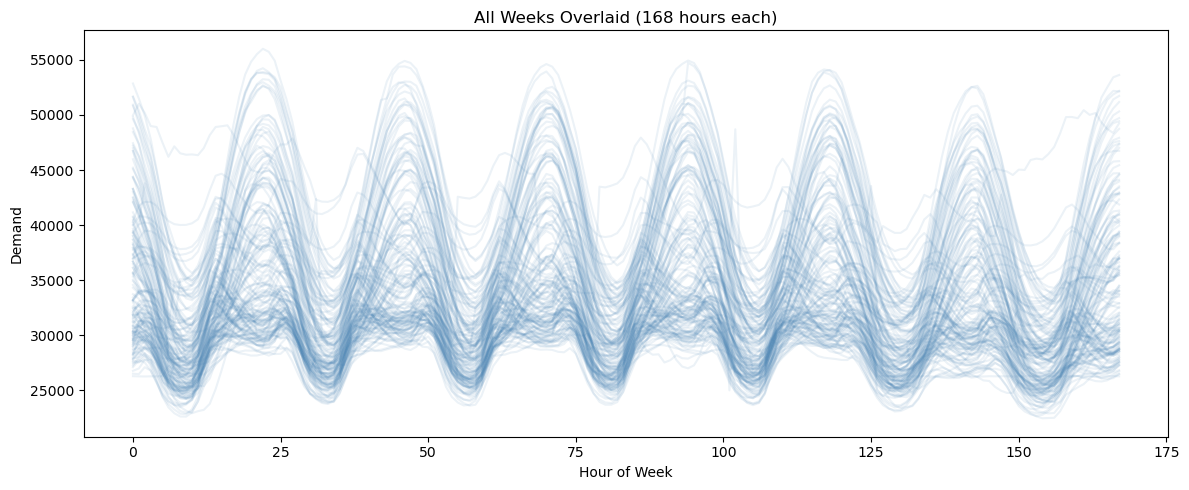

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))

for year_week, group in df.groupby([df.index.year, df.index.isocalendar().week]):
    if len(group) == 168:  # full week only
        ax.plot(range(168), group["Demand"].values, alpha=0.1, color="steelblue")

ax.set_title("All Weeks Overlaid (168 hours each)")
ax.set_xlabel("Hour of Week")
ax.set_ylabel("Demand")
plt.tight_layout()
plt.show()

The data looks better but that are still some large jumps and spikes in the data and an odd flat week at the end

let's test the residuals on a simple 24 lagged model

### Checking base model residuals

In [42]:
# Create forecaster
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
             )
forecaster.fit(y=df['Demand'], store_in_sample_residuals=True)

In [43]:
residuals = pd.Series(forecaster.in_sample_residuals_)

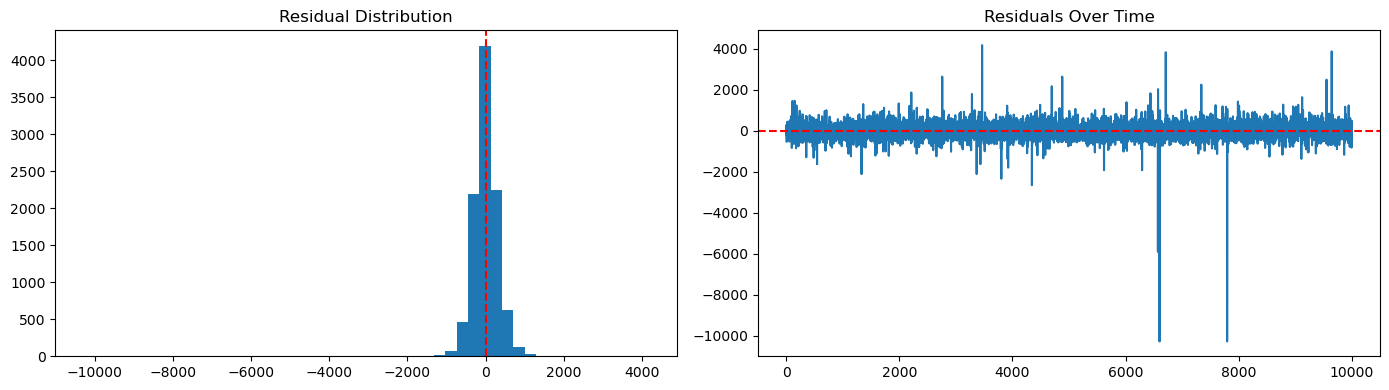

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].hist(residuals, bins=50)
axes[0].set_title("Residual Distribution")
axes[0].axvline(0, color="red", linestyle="--")

# Residuals over index (order they were generated)
axes[1].plot(residuals.values)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals Over Time")

plt.tight_layout()
plt.show()

### How do we fix the flat runs of the data?
- the longest flat rans are both in 2025:
    - 2025/5/27 to 2025/5/25 has a run of 132
    - 2025/12/15 to 2025/12/23 has a run of 177
    - but even surrounding those dates are more shorter flat runs
- Step 1 is dropp the data after 2025/5/19
- Stpe 2 Create weight function for the dates we want the model to ignore
- What date ranges do we want to ignore?
    - we have suspicious_runs with flat runs
    - what about the suspicious_weeks?

In [ ]:
# What groups of data do we want to ig

end results: list of weeks that are bad and to be replaced

In [17]:
#let's write the clean df to csv
df_clean.to_csv("../data/raw/loadtempday_clean.csv", index=True)

In [31]:
print(f"start of data: {df.index.min()}")
print(f"end of data: {df.index.max()}")

start of data: 2023-01-01 00:00:00
end of data: 2025-12-31 23:00:00


### Train Val Test Split
- Train: 2023-01-01 to 2024-06-30 (18 months)
- Validation: 2024-07-01 to 2024-12-31 (6 months)
- Test: 2025-01-01 to 2025-12-31 (12 months)

In [18]:
TRAIN_START = "2023-01-01 00:00:00"
#datetime(2023, 1, 1, 0, 0, 0)
TRAIN_END   = "2024-06-30 23:00:00"
#datetime(2024, 6, 30, 23, 0, 0)

VAL_START   = "2024-07-01 00:00:00"
#datetime(2024, 7, 1, 0, 0, 0)
VAL_END     = "2024-12-31 23:00:00"
#datetime(2024, 12, 31, 23, 0, 0)

TEST_START  = "2025-01-01 00:00:00"
#datetime(2025, 1, 1, 0, 0, 0)
TEST_END    = "2025-12-31 23:00:00"
#datetime(2025, 12, 31, 23, 0, 0)

In [19]:
data = df_clean.copy()
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


### Graphs

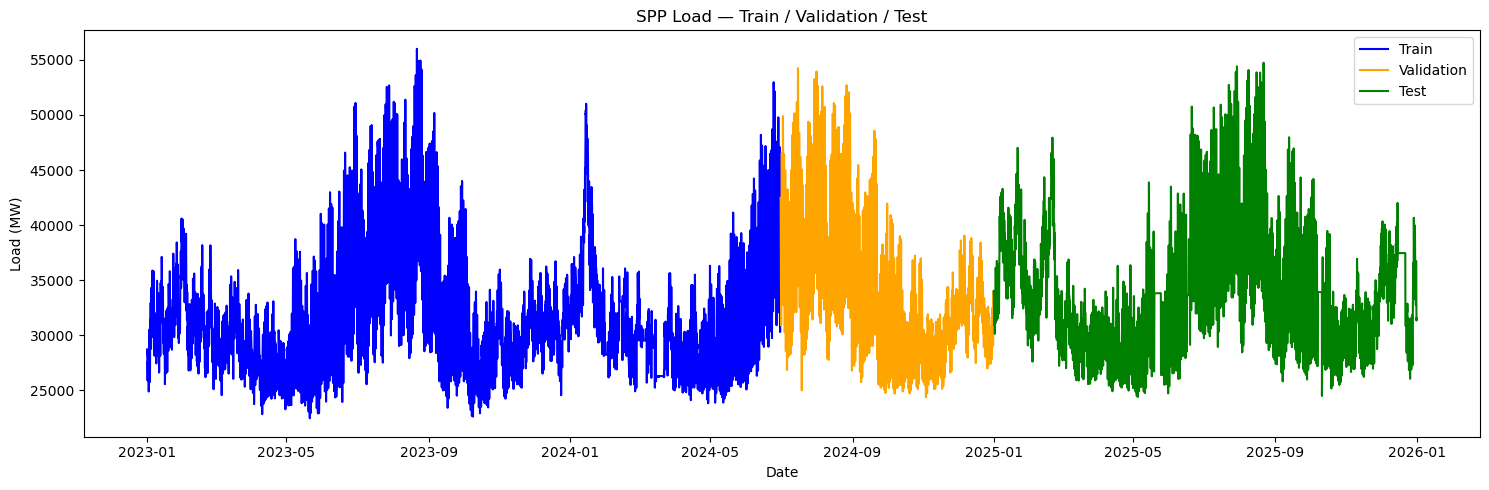

In [20]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_train.index, data_train["Demand"], label="Train", color="blue")
ax.plot(data_val.index, data_val["Demand"], label="Validation", color="orange")
ax.plot(data_test.index, data_test["Demand"], label="Test", color="green")

ax.set_title("SPP Load — Train / Validation / Test")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

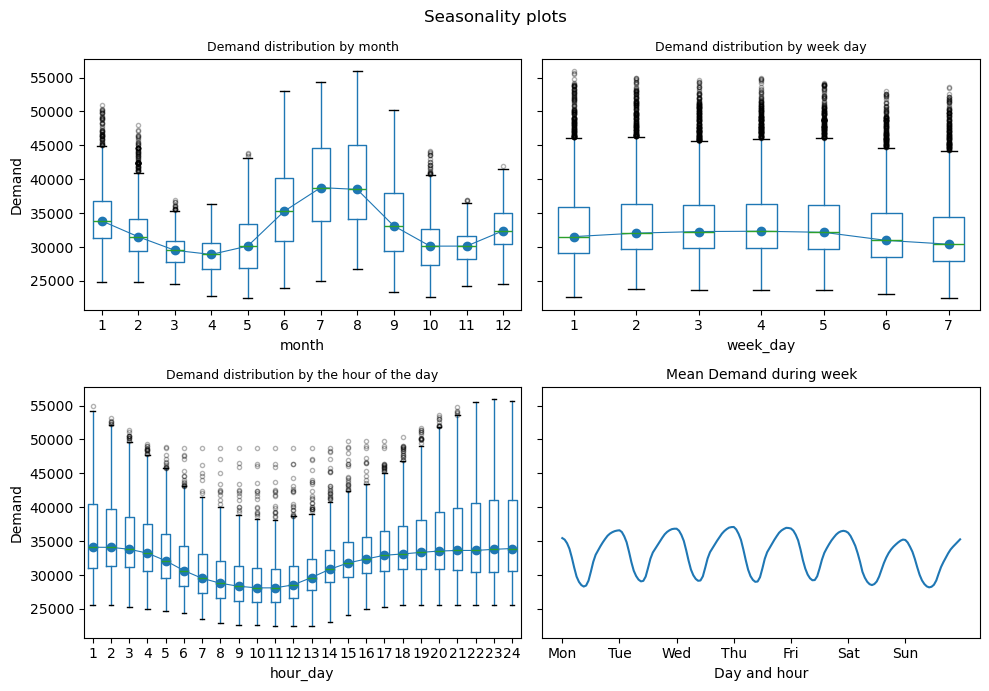

In [22]:
# Annual, weekly and daily seasonality
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=True)
axs = axs.ravel()

# Demand distribution by month
data['month'] = data.index.month
data.boxplot(column='Demand', by='month', ax=axs[0], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('month')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[0])
axs[0].set_ylabel('Demand')
axs[0].set_title('Demand distribution by month', fontsize=9)

# Demand distribution by week day
data['week_day'] = data.index.day_of_week + 1
data.boxplot(column='Demand', by='week_day', ax=axs[1], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('week_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[1])
axs[1].set_ylabel('Demand')
axs[1].set_title('Demand distribution by week day', fontsize=9)

# Demand distribution by the hour of the day
data['hour_day'] = data.index.hour + 1
data.boxplot(column='Demand', by='hour_day', ax=axs[2], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('hour_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[2])
axs[2].set_ylabel('Demand')
axs[2].set_title('Demand distribution by the hour of the day', fontsize=9)

# Demand distribution by week day and hour of the day
mean_day_hour = data.groupby(["week_day", "hour_day"])["Demand"].mean()
mean_day_hour.plot(ax=axs[3])
axs[3].set(
    title       = "Mean Demand during week",
    xticks      = [i * 24 for i in range(7)],
    xticklabels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xlabel      = "Day and hour",
    ylabel      = "Number of Demand"
)
axs[3].title.set_size(10)

fig.suptitle("Seasonality plots", fontsize=12)
fig.tight_layout()

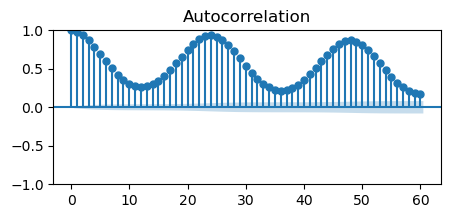

In [25]:
# Autocorrelation plot
fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(data['Demand'], ax=ax, lags=60, fft=True)
plt.show()

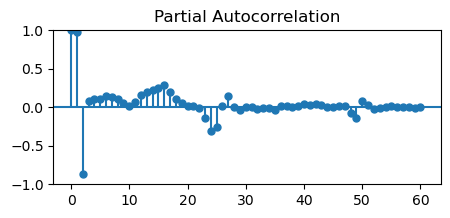

In [26]:
# Partial autocorrelation plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(5, 2))
plot_pacf(data['Demand'], ax=ax, lags=60, method='burg')
plt.show()

In [30]:
# Top 10 lags with the highest absolute partial autocorrelation
# ==============================================================================
calculate_lag_autocorrelation(
    data        = data['Demand'],
    n_lags      = 60,
    sort_by     = "partial_autocorrelation_abs",
    acf_kwargs  = {'fft': True},
    pacf_kwargs = {'method': 'burg'}
).head(10)

,lag,partial_autocorrelation_abs,partial_autocorrelation,autocorrelation_abs,autocorrelation
0,1,0.983448,0.983448,0.983433,0.983433
1,2,0.872132,-0.872132,0.938511,0.938511
2,24,0.313445,-0.313445,0.935476,0.935476
3,16,0.285086,0.285086,0.407027,0.407027
4,15,0.254537,0.254537,0.344922,0.344922
5,25,0.253179,-0.253179,0.918148,0.918148
6,14,0.220455,0.220455,0.299811,0.299811
7,17,0.197577,0.197577,0.483329,0.483329
8,13,0.197410,0.197410,0.273051,0.273051
9,12,0.155309,0.155309,0.265431,0.265431
